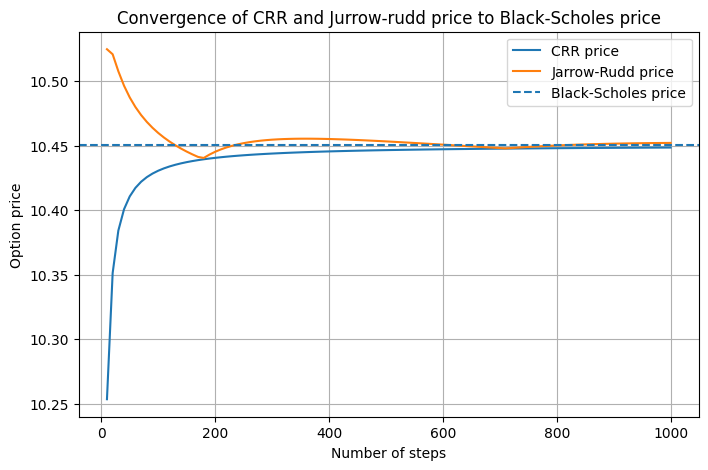

In [9]:
import matplotlib.pyplot as plt

from pathlib import Path
from quant_framework.option import Option
from quant_framework.black_scholes import BlackScholesModel
from quant_framework.binomial_tree import BinomialTreeModel


option = Option(strike=100, maturity=1, type="call")

bs = BlackScholesModel(init_price=100, rate=0.05, volatility=0.2)
black_scholes_price = bs.price(option)

crr_prices = []
steps = [10 * i for i in range(1, 101)]
for step in steps:
    crr = BinomialTreeModel(
        init_price=100,
        rate=0.05,
        volatility=0.2,
        num_of_steps=step,
        model="crr",
    )
    crr_prices.append(crr.price(option))

jr_prices = []
for step in steps:
    jr = BinomialTreeModel(
        init_price=100,
        rate=0.05,
        volatility=0.2,
        num_of_steps=step,
        model="jarrow-rudd",
    )
    jr_prices.append(jr.price(option))

Path("../figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    steps,
    crr_prices,
    linestyle="-",
    label="CRR price"
)
plt.plot(
    steps,
    jr_prices,
    linestyle="-",
    label="Jarrow-Rudd price"
)
plt.axhline(
    y=black_scholes_price,
    linestyle="--",
    label="Black-Scholes price"
)

plt.xlabel("Number of steps")
plt.ylabel("Option price")
plt.title("Convergence of CRR and Jurrow-rudd price to Black-Scholes price")
plt.legend()
plt.grid(True)

plt.savefig("../figures/crr_convergence.png", dpi=300, bbox_inches="tight")
plt.show()
